<a href="https://colab.research.google.com/github/ditodewantoro/DATA-ANALYST/blob/main/Scraping_APP_ML__14105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# mendownload semua lib yang dibutuhkan
!pip install google-play-scraper --quiet

In [ ]:
# import lib yang akan digunakan untuk mengambil reviews dan comment
from google_play_scraper import reviews
import pandas as pd

In [ ]:
# masukan nama aplikasinya
app_id = "com.mobile.legends"

In [ ]:
result, _ = reviews(
    app_id,
    lang='id',
    country='id',
    count=1000,
    filter_score_with=None
)

df_playstore = pd.DataFrame(result)
df_playstore = df_playstore[['userName', 'score', 'content', 'at']]

print("Jumlah ulasan", len(result))

Jumlah ulasan 1000


In [ ]:
print(df_playstore.head())

            userName  score  \
0          Rehan Bcr      5   
1         Faris Aziz      1   
2    Rahmad Saifudin      1   
3       raviah yusuf      5   
4  ariel AbdulRahman      4   

                                             content                  at  
0                   keren asal aku bisa ya ga gessss 2025-06-11 12:50:41  
1  YTH.MOONTON. tolong yh kalo kasih tim itu yg s... 2025-06-11 12:50:30  
2  coba ngasih tim itu jgn drak sistem trus moontoon 2025-06-11 12:49:47  
3  Plis lah moonton kasih gua tim yang bener jang... 2025-06-11 12:49:40  
4                                                 ok 2025-06-11 12:48:23  


In [ ]:
df_playstore.to_csv("ML_komentar.csv", index=False)

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from html import unescape

In [ ]:
# 1. Load the Data
file_path = '/content/ML_komentar.csv'  # Replace with your file path
try:
    df = pd.read_csv(file_path, encoding='utf-8')  # or use encoding='latin1' if needed
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='latin1')  #Try alternative
print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
print(df.columns)

Index(['userName', 'score', 'content', 'at'], dtype='object')


In [ ]:
#Verify file before proceeding
print(df.head()) #print 5 first row
print(df.info()) #get the information of your data

            userName  score  \
0     Ericka Yolanda      5   
1        hanafi syah      1   
2  Muhammad Sholihin      5   
3  Abizar Dirgantara      5   
4        ahmad iqbal      1   

                                             content                   at  
0  udh bagus. tolong dong moonton buat menu berba...  2025-06-06 17:04:54  
1  koonntooollll,,kasih kwn yg betull anjing babi...  2025-06-06 17:03:55  
2                                        mlbbxnaruto  2025-06-06 17:01:58  
3                                                 ok  2025-06-06 17:01:49  
4                      loooll monton diksh time gjls  2025-06-06 17:01:27  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  1000 non-null   object
 1   score     1000 non-null   int64 
 2   content   1000 non-null   object
 3   at        1000 non-null   object
dtypes: int64(1), object

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# NLTK Indonesian Stopwords
# Ensure you have the stopwords downloaded: nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

# Custom Indonesian stopwords
custom_stopwords = {
    'yg', 'utk', 'dgn', 'kpd', 'ttg', 'dr', 'dlm', 'bbrp', 'pd', 'tsb',
    'gak', 'nggak', 'ga', 'gk', 'nya', 'sih', 'dong', 'deh', 'kok', 'nih',
    'saja', 'aja', 'dah', 'kan', 'tuh', 'lho', 'loh', 'tdk', 'jd', 'jg',
    'juga', 'cuma', 'cuman', 'krn', 'sdh', 'udah', 'utk', 'dpt', 'bkn',
    'kyk', 'kayak', 'gini', 'gitu', 'begini', 'begitu', 'biar', 'ayo',
    'mari', 'yuk', 'pas', 'saat', 'wkt', 'waktu', 'hari', 'bln', 'thn',
    'tahun', 'lg', 'lagi', 'sdg', 'sedang', 'akan', 'bs', 'bisa', 'blm'
}
stop_words.update(custom_stopwords)

# Words to keep in their original form
protected_words = {'media', 'data', 'news', 'corpus', 'analisis', 'status'}  # Add more if needed

def clean_text(text):
    try:
        if not isinstance(text, str) or text.strip() == '':
            return ""

        # Decode HTML
        text = unescape(text)

        # Remove emoji
        emoji_pattern = re.compile(
            "[" u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
            u"\U00002500-\U00002BEF"  # chinese char
            u"\U00002702-\U000027B0"
            u"\U000024C2-\U0001F251"
            u"\U0001f926-\U0001f937"
            u"\U00010000-\U0010ffff"
            u"\u2640-\u2642"
            u"\u2600-\u2B55"
            u"\u200d"
            u"\u23cf"
            u"\u23e9"
            u"\u231a"
            u"\ufe0f"  # dingbats
            u"\u3030"
            "]+", flags=re.UNICODE)
        text = emoji_pattern.sub('', text)

        # Remove URLs, mentions, hashtags
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)

        # Remove strange symbols, keep letters, numbers, spaces, &, -
        text = re.sub(r'[^\w\s&-]', '', text)

        # Lowercase
        text = text.lower()

        # Normalize character repetitions
        text = re.sub(r'(.)\1{2,}', r'\1\1', text)

        # Normalize whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        # Tokenization
        tokens = word_tokenize(text)

        # Lemmatization (before stopword filtering)
        tokens = [
            word if word in protected_words else lemmatizer.lemmatize(word)
            for word in tokens
        ]

        # Filter stopwords after lemmatization
        tokens = [word for word in tokens if word not in stop_words]

        # Remove very short words
        tokens = [word for word in tokens if len(word) > 1]

        return ' '.join(tokens)

    except Exception as e:
        print(f"⚠️ Error processing text: {text}\n⛔ Error: {str(e)}")
        return ""

In [ ]:
df['cleaned_text'] = df['content'].astype(str).apply(clean_text) #important to convert to string before cleaning

print("Data cleaning and preprocessing completed.")

Data cleaning and preprocessing completed.


In [ ]:
#Print Original and Cleaned Comments

print("\n--- First 10 Original and Cleaned Comments ---")
for i in range(min(10, len(df))):  # Print up to the first 10 comments
    print(f"Original: {df['content'][i]}")
    print(f"Cleaned:  {df['cleaned_text'][i]}\n")

print("Data cleaning and preprocessing completed.")


--- First 10 Original and Cleaned Comments ---
Original: udh bagus. tolong dong moonton buat menu berbagi ke temen. misalnya berbagi skin/ diamond jdi lebih mudah kalau mau bagi skin tertentu & diamond
Cleaned:  udh bagus tolong moonton menu berbagi temen berbagi skin diamond jdi mudah skin diamond

Original: koonntooollll,,kasih kwn yg betull anjing babi....capekk kali
Cleaned:  koonntoollkasih kwn betull anjing babicapekk kali

Original: mlbbxnaruto
Cleaned:  mlbbxnaruto

Original: ok
Cleaned:  ok

Original: loooll monton diksh time gjls
Cleaned:  looll monton diksh time gjls

Original: game haram, hapus aja game ni dari PlayStore
Cleaned:  game haram hapus game ni playstore

Original: kecewa sama moonton karena sering terjadi di rank pembagian tim yang ga seimbang,cape bngt bolak balik main cuma victory defeat terus mau lari dari ini game jg ga bisa kaya rasa nya pengen main trs padahal asli nya udah stres,cape jg,dan juga ada semacam bug jaringan yang tiba" lemot padahal asli nya 

In [ ]:
# Save original and cleaned comments to a CSV file
df[['content', 'cleaned_text']].to_csv("cleaned_comments.csv", index=False)

print("Cleaned comments saved successfully to cleaned_comments.csv")

Cleaned comments saved successfully to cleaned_comments.csv


In [ ]:
# 3. Exploratory Data Analysis (EDA)
def eda(df):
    """
    Performs exploratory data analysis on the cleaned comments.
    """
    # 3.1. Word Frequency Analysis:
    all_words = ' '.join(df['cleaned_text']).split()
    word_counts = pd.Series(all_words).value_counts().nlargest(20)  # Top 20 words

    plt.figure(figsize=(12, 6))
    sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')
    plt.title('Top 20 Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Word')
    plt.show()

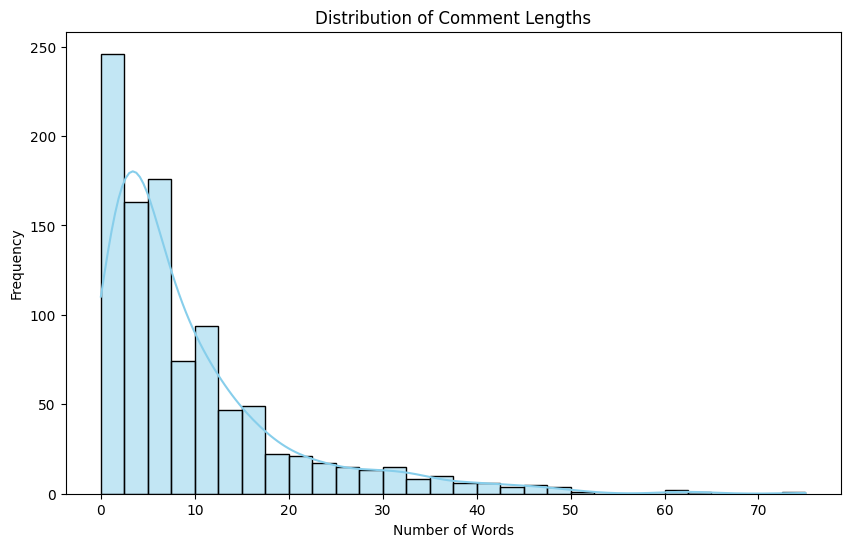

Exploratory data analysis completed.


/tmp/ipython-input-17-121735453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')


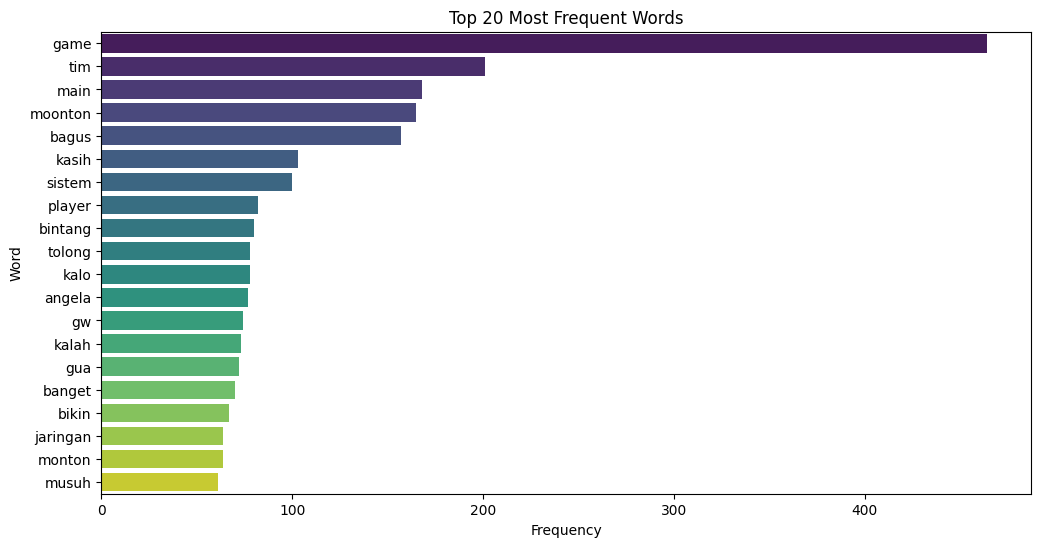

In [ ]:
# 3.2. Comment Length Distribution:
df['comment_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Comment Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()
print("Exploratory data analysis completed.")

eda(df)


In [ ]:
# Function to count word frequency
from collections import Counter

def count_word_frequency(text_series):
    all_words = ' '.join(text_series).split()
    word_counts = Counter(all_words)
    return word_counts

# Get word frequency dictionary
word_freq = count_word_frequency(df['cleaned_text'])

# Convert to DataFrame
word_freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

# Print all word frequencies
print("\nWord Frequency List:")
print(word_freq_df.to_string(index=False))  # Print entire frequency list


Word Frequency List:
                    Word  Frequency
                    game        464
                     tim        201
                    main        168
                 moonton        165
                   bagus        157
                   kasih        103
                  sistem        100
                  player         82
                 bintang         80
                  tolong         78
                    kalo         78
                  angela         77
                      gw         74
                   kalah         73
                     gua         72
                  banget         70
                   bikin         67
                jaringan         64
                  monton         64
                   musuh         61
                    seru         60
                   orang         58
                    mulu         58
                    skin         58
                      ml         57
                      ya         51
      

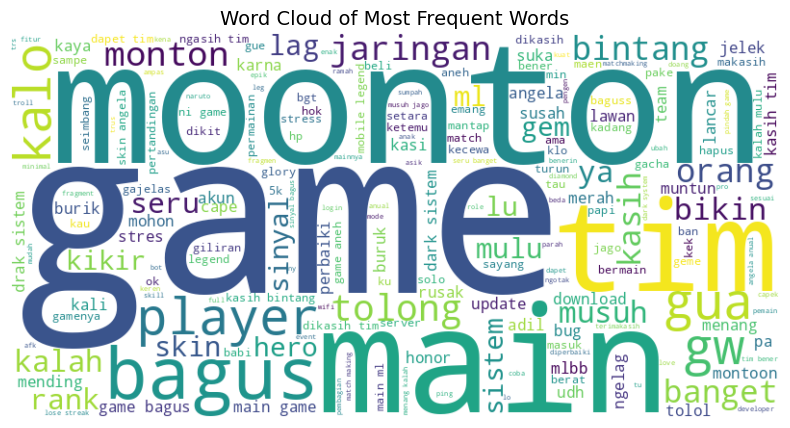

In [ ]:
# Generate Word Cloud

from wordcloud import WordCloud
def generate_wordcloud(text_series):
    text = ' '.join(text_series)
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Word Cloud of Most Frequent Words", fontsize=14)
    plt.show()

# Generate and display the word cloud
generate_wordcloud(df['cleaned_text'])

/tmp/ipython-input-21-3310986620.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigram_df["Frequency"], y=bigram_df["Bigram"].apply(lambda x: ' '.join(x)), palette="magma")


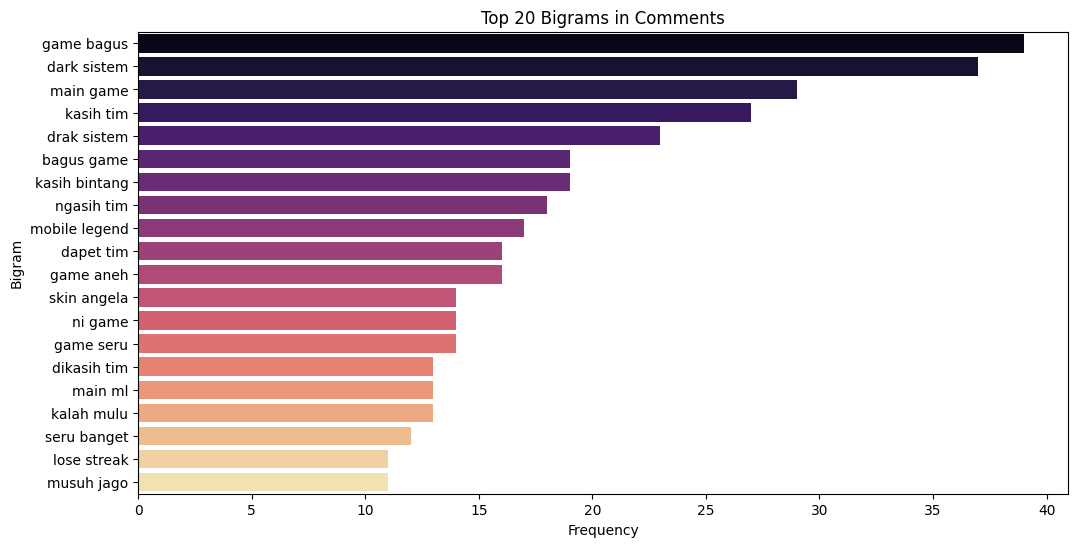

In [ ]:
# Most Frequent Word Pairs
from nltk.util import bigrams

# Generate bigrams
all_words = ' '.join(df['cleaned_text']).split()
bigrams_list = list(bigrams(all_words))

# Count most common bigrams
bigram_counts = Counter(bigrams_list)
bigram_df = pd.DataFrame(bigram_counts.most_common(20), columns=["Bigram", "Frequency"])

# Plot bigram bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=bigram_df["Frequency"], y=bigram_df["Bigram"].apply(lambda x: ' '.join(x)), palette="magma")
plt.title("Top 20 Bigrams in Comments")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()

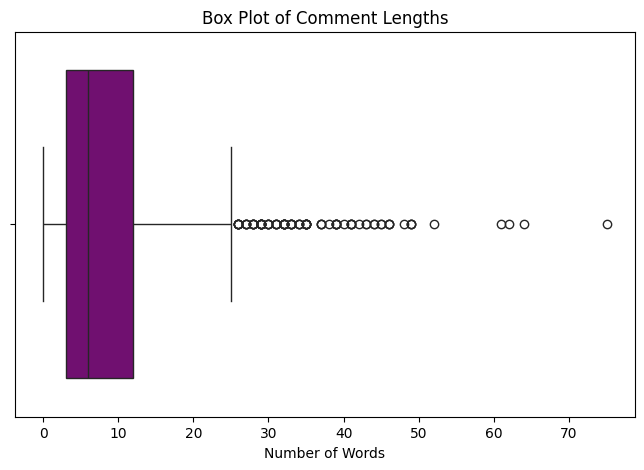

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['comment_length'], color='purple')
plt.title("Box Plot of Comment Lengths")
plt.xlabel("Number of Words")
plt.show()

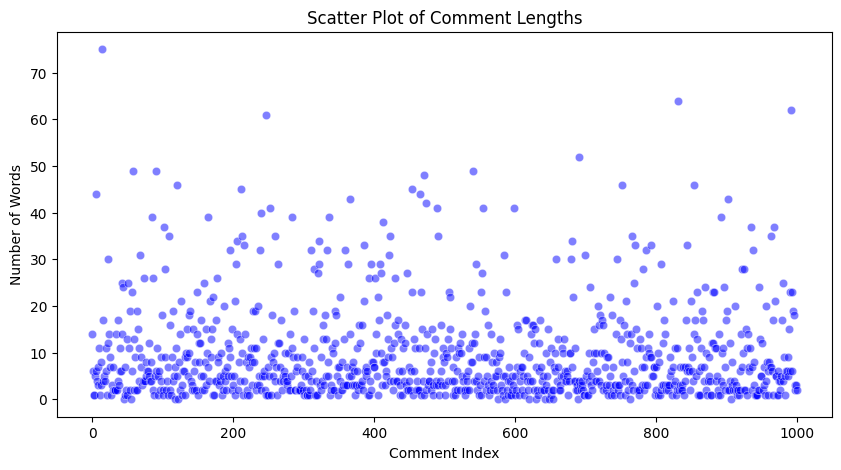

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=range(len(df)), y=df['comment_length'], alpha=0.5, color="blue")
plt.title("Scatter Plot of Comment Lengths")
plt.xlabel("Comment Index")
plt.ylabel("Number of Words")
plt.show()

/tmp/ipython-input-24-3135578455.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=first_word_counts.values, y=first_word_counts.index, palette="coolwarm")


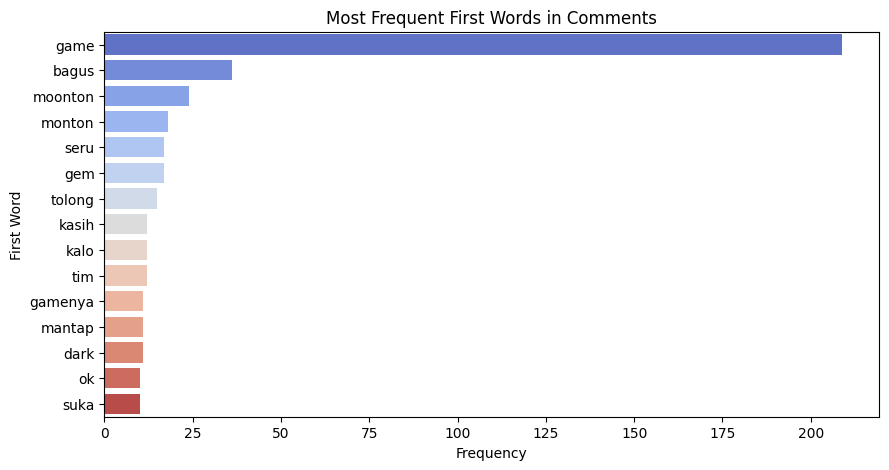

In [ ]:
first_words = df['cleaned_text'].apply(lambda x: x.split()[0] if isinstance(x, str) and x else None)
first_word_counts = first_words.value_counts().nlargest(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=first_word_counts.values, y=first_word_counts.index, palette="coolwarm")
plt.title("Most Frequent First Words in Comments")
plt.xlabel("Frequency")
plt.ylabel("First Word")
plt.show()

**Sentimen Analysis with IndoBERT**

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax

In [ ]:
file_path = 'cleaned_comments.csv'
df = pd.read_csv(file_path)

In [ ]:
# Load IndoBERT pre-trained model and tokenizer
MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)  # 3 labels: Neg, Neu, Pos

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Define sentiment labels
label_mapping = {0: "Positive", 1: "Negative", 2: "Positive"}

def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    probabilities = softmax(outputs.logits, dim=1)
    predicted_label = torch.argmax(probabilities, dim=1).item()
    return label_mapping[predicted_label]

In [ ]:
# Apply sentiment prediction
df['sentiment'] = df['cleaned_text'].astype(str).apply(predict_sentiment)

print(df[['cleaned_text', 'sentiment']].head(50))  # Show first 10 rows

                                         cleaned_text sentiment
0   udh bagus tolong moonton menu berbagi temen be...  Negative
1   koonntoollkasih kwn betull anjing babicapekk kali  Negative
2                                         mlbbxnaruto  Positive
3                                                  ok  Positive
4                        looll monton diksh time gjls  Positive
5                  game haram hapus game ni playstore  Negative
6   kecewa moonton rank pembagian tim seimbangcape...  Negative
7                              game bagus banget suka  Positive
8          thanks lot for angela fragment shop system  Positive
9                                   mb-nya hp kentang  Negative
10  game ngntd gw main trol mulu kntl ilangin dark...  Negative
11                                              kikir  Positive
12           game lu taik bnyak dark sistem game tolo  Negative
13                                   game haram tolol  Positive
14  pless moonton gua dikasih tim jago k

In [ ]:
# Save the results
df.to_csv('cleaned_comments_with_sentiment.csv', index=False)

print("Sentiment labeling completed! File saved as 'cleaned_comments_with_sentiment.csv'")

Sentiment labeling completed! File saved as 'cleaned_comments_with_sentiment.csv'


/tmp/ipython-input-31-1048751036.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


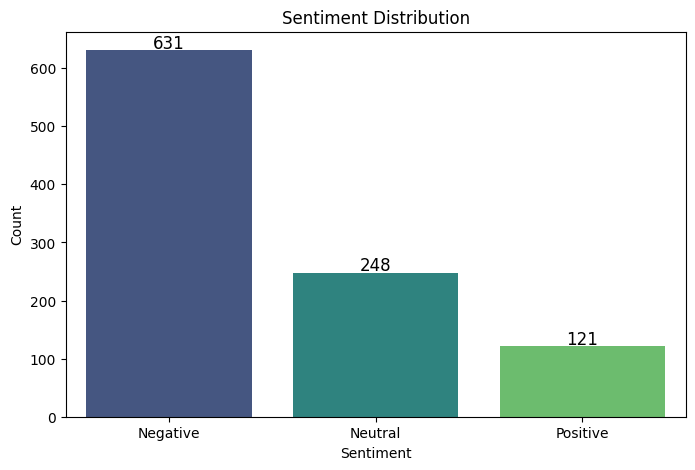

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count sentiment occurrences
sentiment_counts = df['sentiment'].value_counts()

# Plot bar chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")

# Add count annotations on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',  # Format the count number with no decimal places
                (p.get_x() + p.get_width() / 2., p.get_height()),  # Position at the top of each bar
                ha='center', va='center', fontsize=12, color='black',  # Adjust the position and appearance
                xytext=(0, 5), textcoords='offset points')  # Offset the text a bit above the bar

plt.show()

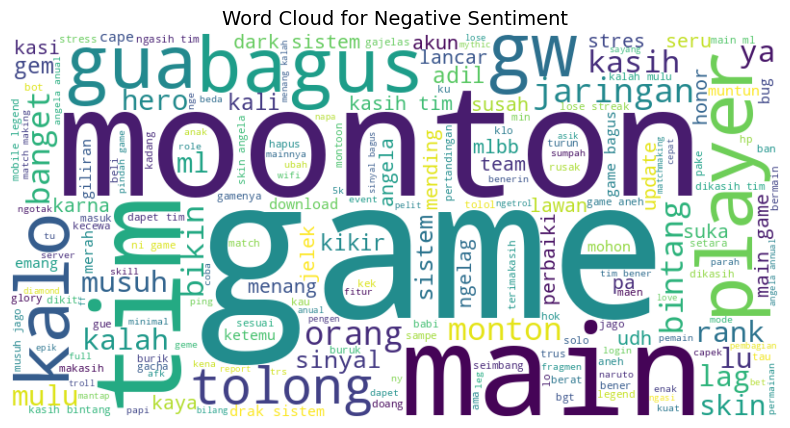

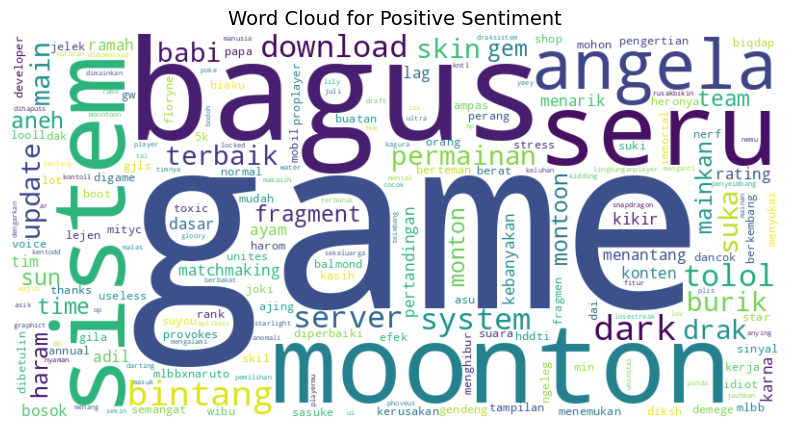

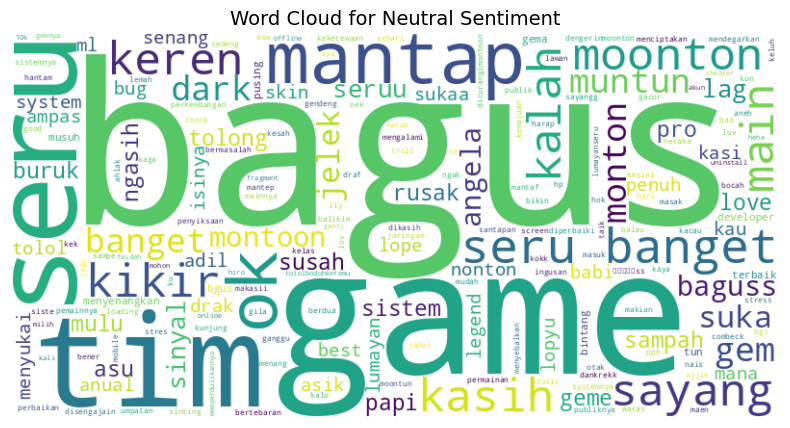

In [ ]:
def generate_sentiment_wordcloud(df, sentiment_label):
    """
    Generates and displays a word cloud for a specific sentiment.
    """
    # Replace NaN with empty string and join text
    text = ' '.join(df[df['sentiment'] == sentiment_label]['cleaned_text'].fillna('')).split()

    # Filter out short tokens (e.g., single letters)
    text = [word for word in text if len(word) > 1]
    text = ' '.join(text)

    if not text.strip(): # Check if text is empty or only whitespace
        print(f"No text found for sentiment: {sentiment_label}")
        return

    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for {sentiment_label} Sentiment", fontsize=14)
    plt.show()

# Generate word clouds for each sentiment
for sentiment in df['sentiment'].unique():
    generate_sentiment_wordcloud(df, sentiment)


In [ ]:
!pip install bertopic --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 877.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 36.8 MB/s eta 0:00:00


In [ ]:
from bertopic import BERTopic
import pandas as pd

# Inisialisasi model BERTopic
topic_model = BERTopic(min_topic_size=15, verbose=True, n_gram_range=(1, 2))

# Fit BERTopic pada data yang sudah dibersihkan
# Fill NaN values in 'cleaned_text' with empty strings
cleaned_text_for_bertopic = df['cleaned_text'].fillna('')
topics, probabilities = topic_model.fit_transform(cleaned_text_for_bertopic)

# Menampilkan informasi topik yang terbentuk
topic_info = topic_model.get_topic_info()
print("\nHasil Analisis BERTopic:")
print(topic_info)

# Visualisasi topik yang terbentuk
topic_model.visualize_topics()

# Visualisasi distribusi antar topik
topic_model.visualize_documents(cleaned_text_for_bertopic)

# Visualisasi hierarki topik
topic_model.visualize_hierarchy()

# Jika ingin menampilkan topik-topik tertentu
# Dapat menggunakan fungsi get_topic() untuk menampilkan topik tertentu berdasarkan ID
topik_tertentu = topic_model.get_topic(0)  # misalnya topik ID 0
print("\nTopik ID 0:", topik_tertentu)

2025-07-07 08:55:07,910 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2025-07-07 08:55:30,354 - BERTopic - Embedding - Completed ✓
2025-07-07 08:55:30,355 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-07-07 08:55:44,193 - BERTopic - Dimensionality - Completed ✓
2025-07-07 08:55:44,195 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-07-07 08:55:44,246 - BERTopic - Cluster - Completed ✓
2025-07-07 08:55:44,253 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-07-07 08:55:44,332 - BERTopic - Representation - Completed ✓



Hasil Analisis BERTopic:
   Topic  Count                                   Name  \
0     -1     47            -1_baguss_mantap_suka_sukaa   
1      0    788                0_game_tim_main_moonton   
2      1     36  1_bagus_bagus bagus_keren_keren bagus   
3      2     34                2_ok_good_ok ok_bad luv   
4      3     29    3_kikir_game kikir_game_kikir kikir   
5      4     29   4_seru_game seru_seru seru_seru game   
6      5     19     5_game bagus_bagus_bagus game_game   
7      6     18  6_banget_seru banget_seru_banget seru   

                                      Representation  \
0  [baguss, mantap, suka, sukaa, menyukai, suka g...   
1  [game, tim, main, moonton, kasih, sistem, bagu...   
2  [bagus, bagus bagus, keren, keren bagus, bagus...   
3  [ok, good, ok ok, bad luv, good goodluck, aj g...   
4  [kikir, game kikir, game, kikir kikir, ak, poi...   
5  [seru, game seru, seru seru, seru game, seruu,...   
6  [game bagus, bagus, bagus game, game, ar you, ...   
7  

In [ ]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.5 MB/s eta 0:00:00


In [ ]:
# Untuk mengekspor visualisasi topik ke file gambar
topic_model.visualize_topics()

In [ ]:
# Untuk mengekspor visualisasi distribusi dokumen antar topik ke file gambar
topic_model.visualize_documents(cleaned_text_for_bertopic)

In [ ]:
# Untuk mengekspor visualisasi hierarki topik ke file gambar
topic_model.visualize_hierarchy()